# 08 | Learned ranking evaluation

**Question:** Does a learned ranker improve ordered top-20 recommendations over source agreement and reciprocal-rank fusion on exactly the same candidate pool?

This notebook presents the completed three-objective Fold 0 experiment on **103,468 outer sessions**, with 100 candidates per session/objective. It reads measured artifacts; it never starts training. Inner sessions select the stopping iteration independently of outer ranking evaluation.

**Scope:** exploratory nested session validation, not an untouched temporal test. Frozen upstream retriever fit provenance remains uncertified. The 30-feature model is a baseline for feature research, not the requested exhaustive feature search or a leaderboard submission.


In [1]:
import hashlib
import json
import math
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.ticker import PercentFormatter

root = Path.cwd() if (Path.cwd() / 'reports').is_dir() else Path.cwd().parent
path = root / 'reports/metrics/ranking_evaluation.json'
report = json.loads(path.read_text())
provenance = json.loads((root / 'reports/metrics/ranking_evaluation_provenance.json').read_text())
assert hashlib.sha256(path.read_bytes()).hexdigest() == provenance['metrics_sha256']
assert report['status'] == provenance['status'] == 'passed'
assert report['run_id'] == provenance['run_id']
assert report['untouched_temporal_holdout'] is False
objectives = ['clicks', 'carts', 'orders']
weights = dict(zip(objectives, [0.1, 0.3, 0.6]))
for system in ('learned', 'baseline'):
    weighted = 0.0
    for objective in objectives:
        parts = [fold['objectives'][objective][system] for fold in report['folds']]
        hits = sum(part['hits'] for part in parts)
        denominator = sum(part['denominator'] for part in parts)
        saved = report[system]['objectives'][objective]
        assert saved['hits'] == hits and saved['denominator'] == denominator
        assert math.isclose(saved['recall_at_20'], hits / denominator, rel_tol=1e-12)
        weighted += weights[objective] * hits / denominator
    assert math.isclose(weighted, report[system]['weighted_recall_at_20'], rel_tol=1e-12)
print('Verified at UTC:', datetime.now(UTC).isoformat())
print('Run:', report['run_id'])
print('Scope:', report['validation_scope'])
print('Candidate budget:', report['candidate_k'], '| Model features:', provenance['model_feature_count'])


Verified at UTC: 2026-09-10T04:19:12.900461+00:00
Run: b2804b2a1495d60f7e9286dda93dd9c493eafd982bed7c41af6b08b7e904e220
Scope: exploratory nested session validation; frozen baseline provenance uncertified
Candidate budget: 100 | Model features: 30


## Official score | matched comparison

The weights are 10% clicks, 30% carts and 60% orders. True-item denominators are capped at 20 per session and pooled within each objective. Zero-candidate labeled queries remain misses. Fold counts are pooled before weights are applied; the preceding cell independently checks the arithmetic.

This matched source-agreement/RRF baseline is **not** the earlier all-fold revisit/time benchmark. Different cohorts and candidate policies must not be treated as a controlled comparison. A positive point-estimate change is not a claim of statistical significance.


In [2]:
rows = []
for objective in objectives:
    baseline = report['baseline']['objectives'][objective]
    learned = report['learned']['objectives'][objective]
    rows.append({'Objective': objective, 'Baseline Recall@20': baseline['recall_at_20'],
                 'LambdaRank Recall@20': learned['recall_at_20'],
                 'Change (percentage points)': 100 * (learned['recall_at_20'] - baseline['recall_at_20']),
                 'Hits': learned['hits'], 'Full denominator': learned['denominator']})
scores = pd.DataFrame(rows).set_index('Objective')
display(scores.style.format({'Baseline Recall@20': '{:.3%}', 'LambdaRank Recall@20': '{:.3%}',
    'Change (percentage points)': '{:+.3f}', 'Hits': '{:,}', 'Full denominator': '{:,}'}))
base = report['baseline']['weighted_recall_at_20']
learned = report['learned']['weighted_recall_at_20']
print(f'Official weighted Recall@20: baseline={base:.6f}; LambdaRank={learned:.6f}')
print(f'Absolute change: {100 * (learned - base):+.3f} percentage points')


,Baseline Recall@20,LambdaRank Recall@20,Change (percentage points),Hits,Full denominator
Objective,,,,,
clicks,37.802%,52.071%,+14.269,"52,362","100,559"
carts,26.782%,37.450%,+10.669,"12,732","33,997"
orders,42.490%,55.482%,+12.993,"11,137","20,073"


Official weighted Recall@20: baseline=0.373086; LambdaRank=0.497317
Absolute change: +12.423 percentage points


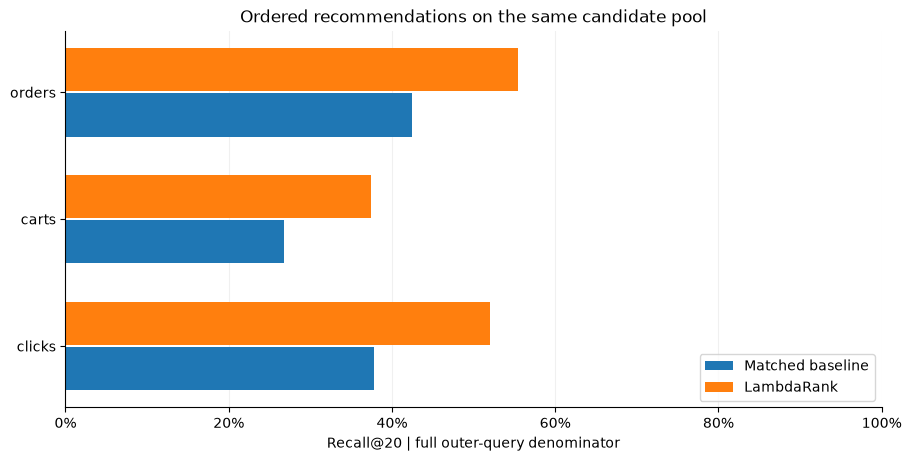

In [3]:
positions = np.arange(len(objectives))
fig, ax = plt.subplots(figsize=(9, 4.5), layout='constrained')
ax.barh(positions - 0.18, scores['Baseline Recall@20'], height=0.34, label='Matched baseline')
ax.barh(positions + 0.18, scores['LambdaRank Recall@20'], height=0.34, label='LambdaRank')
ax.set(yticks=positions, yticklabels=objectives, xlim=(0, 1),
       xlabel='Recall@20 | full outer-query denominator',
       title='Ordered recommendations on the same candidate pool')
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.18)
ax.set_axisbelow(True)
ax.legend(loc='lower right')
plt.show()


## Coverage, selection and engineering cost

Candidate coverage is the ideal top-20 ceiling of this **100-item** pool, not achieved ranking quality. Larger-pool ceilings from notebook 06 cannot be substituted for it. NDCG and MRR average over labeled queries and complement the official metric.

The selected iteration uses inner Recall@20 only. Retained fit time survives resume. Outer evaluation duration includes loading, prediction, sorting and metrics; it is not serving latency. The recorded end-to-end pipeline duration includes candidate preparation and publication, so it differs from model fit time.


,Fold,Objective,Candidate ceiling,Recall@20,NDCG@20,MRR@20,Best iteration,Inner Recall@20,Retained fit seconds,Outer evaluation seconds
0,0,clicks,0.6554,0.5207,0.3588,0.3112,295,0.5154,1525.3675,41.6329
1,0,carts,0.4632,0.3745,0.4175,0.4396,162,0.3837,935.8495,30.9356
2,0,orders,0.6053,0.5548,0.6081,0.6765,115,0.5629,684.7478,23.2034


Weighted candidate ceiling: 0.567721
Within-pool ranking headroom: 7.040 percentage points
Recorded end-to-end pipeline: 135.04 minutes
Broad feature screening performed: False
Feature-family ablations performed: False


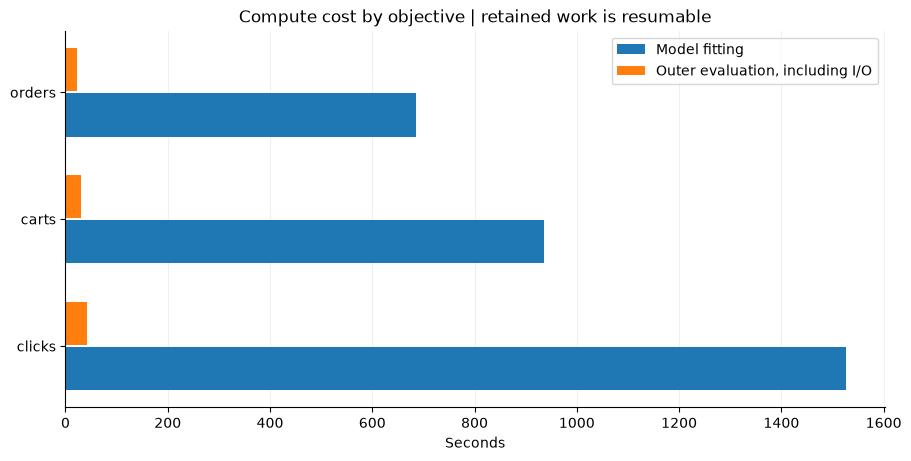

In [4]:
diagnostics = []
for fold in report['folds']:
    for objective in objectives:
        result = fold['objectives'][objective]
        metric = result['learned']
        diagnostics.append({'Fold': fold['outer_fold'], 'Objective': objective,
            'Candidate ceiling': metric['candidate_ceiling_at_20'],
            'Recall@20': metric['recall_at_20'], 'NDCG@20': metric['ndcg_at_20'],
            'MRR@20': metric['mrr_at_20'], 'Best iteration': result['best_iteration'],
            'Inner Recall@20': result['inner_recall_at_20'],
            'Retained fit seconds': result['retained_fit_seconds'],
            'Outer evaluation seconds': result['evaluation_seconds']})
diagnostics = pd.DataFrame(diagnostics)
display(diagnostics.round(4))
ceiling = sum(weights[objective] * sum(
    fold['objectives'][objective]['learned']['candidate_ceiling_at_20'] *
    fold['objectives'][objective]['learned']['denominator'] for fold in report['folds']) /
    report['learned']['objectives'][objective]['denominator'] for objective in objectives)
print(f'Weighted candidate ceiling: {ceiling:.6f}')
print(f'Within-pool ranking headroom: {100 * (ceiling - learned):.3f} percentage points')
print(f"Recorded end-to-end pipeline: {provenance['pipeline_elapsed_seconds'] / 60:.2f} minutes")
print('Broad feature screening performed:', provenance['broad_feature_screening_performed'])
print('Feature-family ablations performed:', provenance['feature_family_ablations_performed'])
timing = diagnostics.groupby('Objective')[
    ['Retained fit seconds', 'Outer evaluation seconds']].sum().reindex(objectives)
fig, ax = plt.subplots(figsize=(9, 4.5), layout='constrained')
ax.barh(positions - 0.18, timing['Retained fit seconds'], height=0.34, label='Model fitting')
ax.barh(positions + 0.18, timing['Outer evaluation seconds'], height=0.34,
        label='Outer evaluation, including I/O')
ax.set(yticks=positions, yticklabels=objectives, xlabel='Seconds',
       title='Compute cost by objective | retained work is resumable')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.18)
ax.set_axisbelow(True)
ax.legend()
plt.show()


## Decision | expand retrieval and feature evidence together

The learned rankers improve all three objectives over the matched baseline. Additional ranking features cannot recover a relevant item excluded by candidate compression. This motivated a larger, controlled feature study; it did not establish the 100-candidate pool as optimal.

This baseline uses source evidence, agreement, observed context and repeat/recency features. Its 30-feature result alone does not establish the utility of hundreds or thousands of features. The completed follow-up in [notebook 09](09_controlled_feature_study.ipynb) engineers 1,482 formulas, screens them using training sessions only, compares eight matched configurations and evaluates sealed models on a newly reserved temporal cohort. It includes candidate ceilings, paired session uncertainty, feature explanations, cost and failure analysis.

The current notebook preserves the original exploratory Fold 0 result; it is not an untouched temporal holdout. Its earlier neural provenance and label-cache limitations are not retroactively changed by the new experiment. Model checksums in these source receipts are recorded; the independent native-model and event audit for the new study is documented in notebook 09. [Notebook 10](10_competition_inference.ipynb) supplies the separate full-data inference workflow and exact native-model replay. No Kaggle submission is implied.

[Ranking methodology](../docs/RANKING.md) · [ANN evidence](06_ann_benchmark.ipynb) · [Feature and split audit](07_ranking_features.ipynb)
